# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Amazon Dataset](https://www.kaggle.com/datasets/prabhanshukamal2121/e-commerce-recommendation?select=amazon_synthetic_data_abandonment_propensity_32_features.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('amazon_synthetic_data_abandonment_propensity_32_features.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,user_id,session_id,customer_tier,account_age_days,past_purchases_count,total_lifetime_value,average_order_value,days_since_last_purchase,days_since_last_discount,device_type,browser,traffic_source,user_location_region,day_of_week,hour_of_day,is_weekend,is_holiday,session_duration_seconds,pages_viewed,distinct_categories_viewed,pdp_views_count,images_viewed_count,reviews_read_count,scroll_depth_average_pct,add_to_cart_count,remove_from_cart_count,wishlist_add_count,cart_value_abandoned,shipping_cost_displayed,exit_intent_triggered,did_convert_organically,should_receive_discount
0,CUST_00001,SESS_000001,Standard,853,1,45.98,45.98,12,25,Mobile,Chrome,Paid Ad,Europe,4,3,0,0,1839,24,2,8,19,4,0.24,0,0,0,0.0,0.00,0,0,0
1,CUST_00002,SESS_000002,Prime Student,257,10,1416.37,141.64,175,0,Mobile,App,Social,North America,0,16,0,0,2284,21,1,9,18,3,0.12,1,0,0,81.9,9.99,0,0,0
2,CUST_00003,SESS_000003,Prime,1411,3,448.10,149.37,183,29,Mobile,Chrome,Social,North America,5,1,1,0,2031,21,1,9,35,1,0.75,0,0,0,0.0,0.00,1,0,0
3,CUST_00004,SESS_000004,Standard,44,8,714.27,89.28,343,46,Mobile,Safari,Organic Search,Oceania,6,21,1,0,734,9,1,4,14,4,0.18,0,0,0,0.0,0.00,0,0,0
4,CUST_00005,SESS_000005,Guest,268,17,2344.24,137.90,235,59,Mobile,Chrome,Organic Search,Oceania,0,17,0,0,606,15,1,8,31,5,0.60,0,0,3,0.0,0.00,0,0,0


## last Five row

In [4]:
df.tail()

,user_id,session_id,customer_tier,account_age_days,past_purchases_count,total_lifetime_value,average_order_value,days_since_last_purchase,days_since_last_discount,device_type,browser,traffic_source,user_location_region,day_of_week,hour_of_day,is_weekend,is_holiday,session_duration_seconds,pages_viewed,distinct_categories_viewed,pdp_views_count,images_viewed_count,reviews_read_count,scroll_depth_average_pct,add_to_cart_count,remove_from_cart_count,wishlist_add_count,cart_value_abandoned,shipping_cost_displayed,exit_intent_triggered,did_convert_organically,should_receive_discount
19995,CUST_19996,SESS_019996,Prime,69,2,211.56,105.78,278,11,Mobile,App,Paid Ad,Asia,5,12,1,0,591,12,3,8,10,13,0.22,2,0,0,148.67,4.99,0,1,0
19996,CUST_19997,SESS_019997,Guest,184,0,0.00,0.00,-1,-1,Mobile,Chrome,Email,Europe,5,6,1,0,842,8,1,6,7,8,0.75,0,0,0,0.00,0.00,0,0,0
19997,CUST_19998,SESS_019998,Standard,1461,6,142.03,23.67,108,19,Mobile,Chrome,Organic Search,North America,0,22,0,0,325,3,2,1,2,0,0.18,1,0,3,289.24,0.00,0,0,0
19998,CUST_19999,SESS_019999,Standard,571,34,3592.68,105.67,52,30,Mobile,Safari,Paid Ad,North America,4,12,0,0,706,26,2,12,50,15,0.80,1,2,0,0.00,0.00,1,0,0
19999,CUST_20000,SESS_020000,Guest,1497,4,306.61,76.65,348,15,Mobile,Chrome,Paid Ad,North America,5,4,1,0,1110,23,2,7,15,5,0.38,0,0,0,0.00,0.00,0,0,1


## Shape of our dataset

In [5]:
df.shape

(20000, 32)

## List out all columns

In [6]:
df.columns

Index(['user_id', 'session_id', 'customer_tier', 'account_age_days',
       'past_purchases_count', 'total_lifetime_value', 'average_order_value',
       'days_since_last_purchase', 'days_since_last_discount', 'device_type',
       'browser', 'traffic_source', 'user_location_region', 'day_of_week',
       'hour_of_day', 'is_weekend', 'is_holiday', 'session_duration_seconds',
       'pages_viewed', 'distinct_categories_viewed', 'pdp_views_count',
       'images_viewed_count', 'reviews_read_count', 'scroll_depth_average_pct',
       'add_to_cart_count', 'remove_from_cart_count', 'wishlist_add_count',
       'cart_value_abandoned', 'shipping_cost_displayed',
       'exit_intent_triggered', 'did_convert_organically',
       'should_receive_discount'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

user_id                        object
session_id                     object
customer_tier                  object
account_age_days                int64
past_purchases_count            int64
total_lifetime_value          float64
average_order_value           float64
days_since_last_purchase        int64
days_since_last_discount        int64
device_type                    object
browser                        object
traffic_source                 object
user_location_region           object
day_of_week                     int64
hour_of_day                     int64
is_weekend                      int64
is_holiday                      int64
session_duration_seconds        int64
pages_viewed                    int64
distinct_categories_viewed      int64
pdp_views_count                 int64
images_viewed_count             int64
reviews_read_count              int64
scroll_depth_average_pct      float64
add_to_cart_count               int64
remove_from_cart_count          int64
wishlist_add

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     20000 non-null  object 
 1   session_id                  20000 non-null  object 
 2   customer_tier               20000 non-null  object 
 3   account_age_days            20000 non-null  int64  
 4   past_purchases_count        20000 non-null  int64  
 5   total_lifetime_value        20000 non-null  float64
 6   average_order_value         20000 non-null  float64
 7   days_since_last_purchase    20000 non-null  int64  
 8   days_since_last_discount    20000 non-null  int64  
 9   device_type                 20000 non-null  object 
 10  browser                     20000 non-null  object 
 11  traffic_source              20000 non-null  object 
 12  user_location_region        20000 non-null  object 
 13  day_of_week                 200

## Check Null Value

In [9]:
df.isnull().sum()

user_id                       0
session_id                    0
customer_tier                 0
account_age_days              0
past_purchases_count          0
total_lifetime_value          0
average_order_value           0
days_since_last_purchase      0
days_since_last_discount      0
device_type                   0
browser                       0
traffic_source                0
user_location_region          0
day_of_week                   0
hour_of_day                   0
is_weekend                    0
is_holiday                    0
session_duration_seconds      0
pages_viewed                  0
distinct_categories_viewed    0
pdp_views_count               0
images_viewed_count           0
reviews_read_count            0
scroll_depth_average_pct      0
add_to_cart_count             0
remove_from_cart_count        0
wishlist_add_count            0
cart_value_abandoned          0
shipping_cost_displayed       0
exit_intent_triggered         0
did_convert_organically       0
should_r

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,account_age_days,past_purchases_count,total_lifetime_value,average_order_value,days_since_last_purchase,days_since_last_discount,day_of_week,hour_of_day,is_weekend,is_holiday,session_duration_seconds,pages_viewed,distinct_categories_viewed,pdp_views_count,images_viewed_count,reviews_read_count,scroll_depth_average_pct,add_to_cart_count,remove_from_cart_count,wishlist_add_count,cart_value_abandoned,shipping_cost_displayed,exit_intent_triggered,did_convert_organically,should_receive_discount
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,897.706700,9.029350,766.115538,76.333816,165.001950,39.56825,2.987600,11.384050,0.279500,0.051250,1016.803000,15.037400,1.675800,7.776300,21.546300,6.320800,0.548948,0.852200,0.201550,0.347750,62.808770,1.628307,0.150550,0.152800,0.143850
std,518.626125,9.517968,940.249991,43.771779,114.176062,28.32473,1.989282,6.915067,0.448765,0.220513,769.369748,8.354316,0.791407,5.097956,15.586549,5.354888,0.259505,1.103275,0.510726,0.787052,92.793423,3.092370,0.357619,0.359804,0.350946
min,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.00000,0.000000,0.000000,0.000000,0.000000,15.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,447.000000,2.000000,147.392500,41.507500,61.000000,14.00000,1.000000,5.000000,0.000000,0.000000,395.000000,8.000000,1.000000,3.000000,8.000000,1.000000,0.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,900.000000,6.000000,440.400000,77.355000,163.000000,39.00000,3.000000,11.000000,0.000000,0.000000,826.000000,15.000000,1.000000,7.000000,18.000000,5.000000,0.550000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1347.000000,13.000000,1018.680000,113.772500,265.000000,64.00000,5.000000,17.000000,1.000000,0.000000,1492.000000,22.000000,2.000000,11.000000,33.000000,11.000000,0.770000,1.000000,0.000000,0.000000,120.565000,0.000000,0.000000,0.000000,0.000000
max,1799.000000,99.000000,9025.620000,149.990000,364.000000,89.00000,6.000000,23.000000,1.000000,1.000000,3472.000000,29.000000,5.000000,20.000000,50.000000,15.000000,1.000000,4.000000,2.000000,3.000000,299.970000,9.990000,1.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

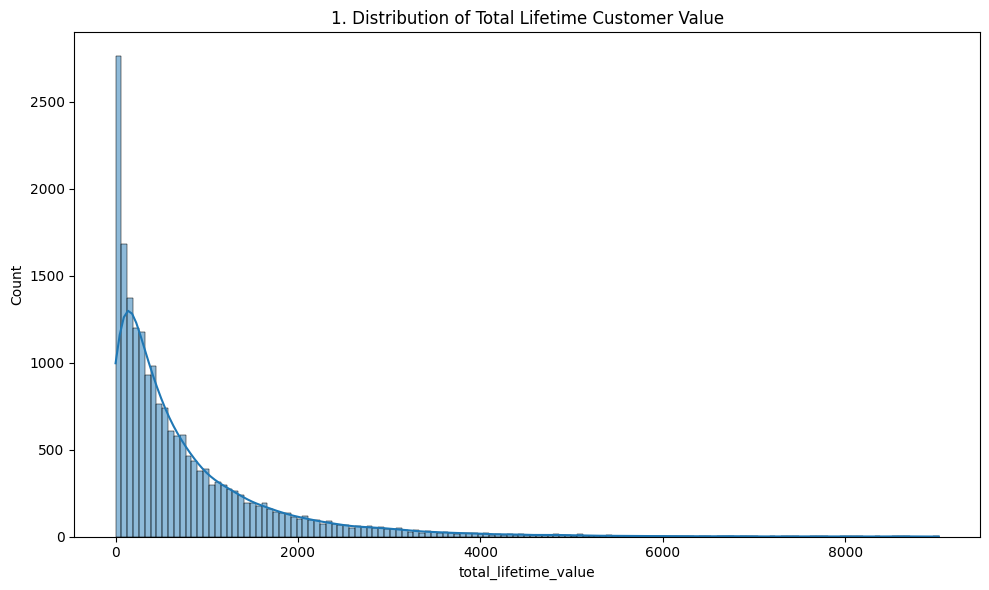

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['total_lifetime_value'], kde=True)
plt.title(f'{plot_no}. Distribution of Total Lifetime Customer Value')
show_fig()
plot_no += 1

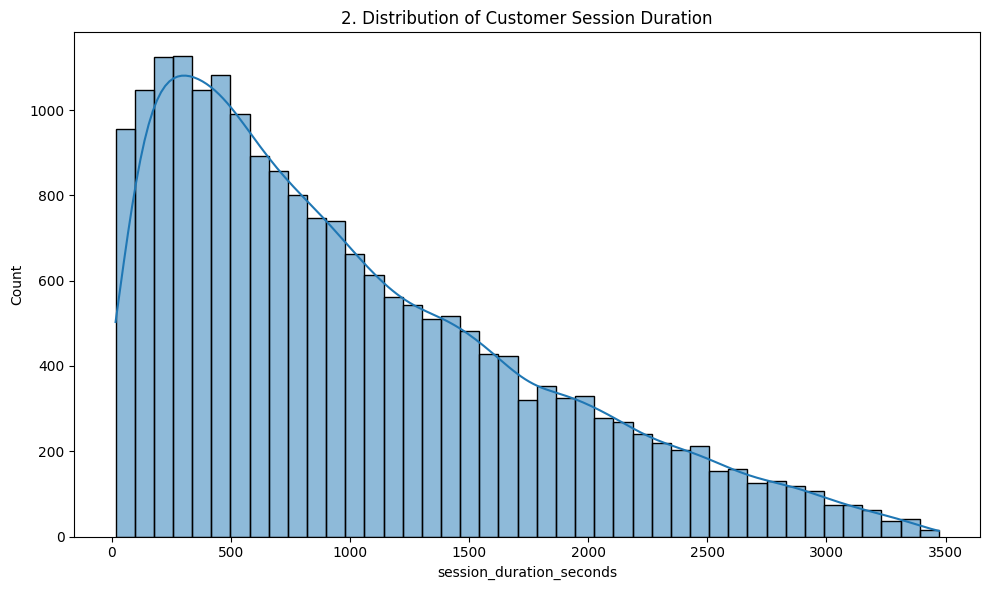

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['session_duration_seconds'], kde=True)
plt.title(f'{plot_no}. Distribution of Customer Session Duration')
show_fig()
plot_no += 1

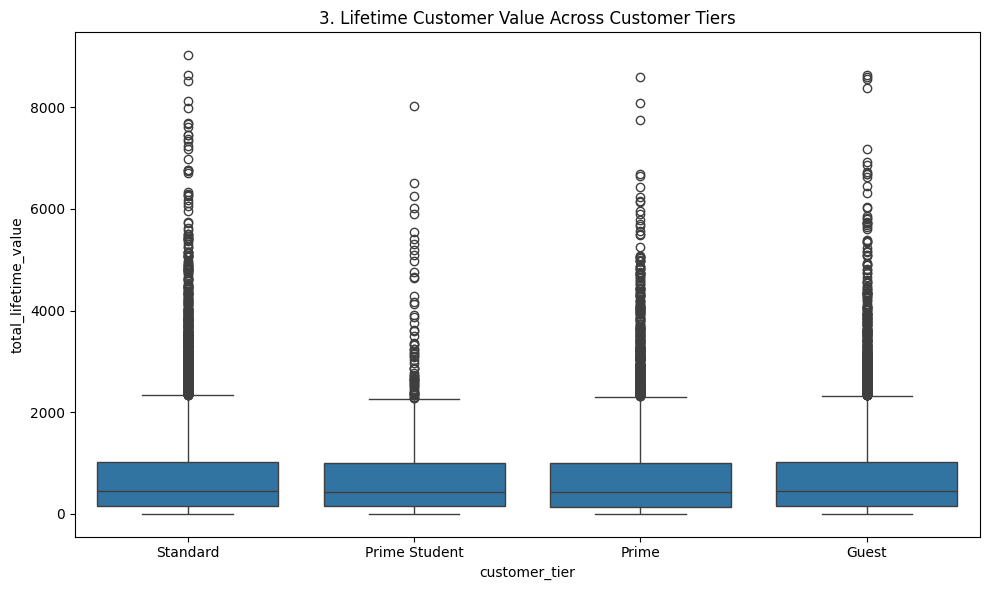

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='customer_tier', y='total_lifetime_value')
plt.title(f'{plot_no}. Lifetime Customer Value Across Customer Tiers')
show_fig()
plot_no += 1

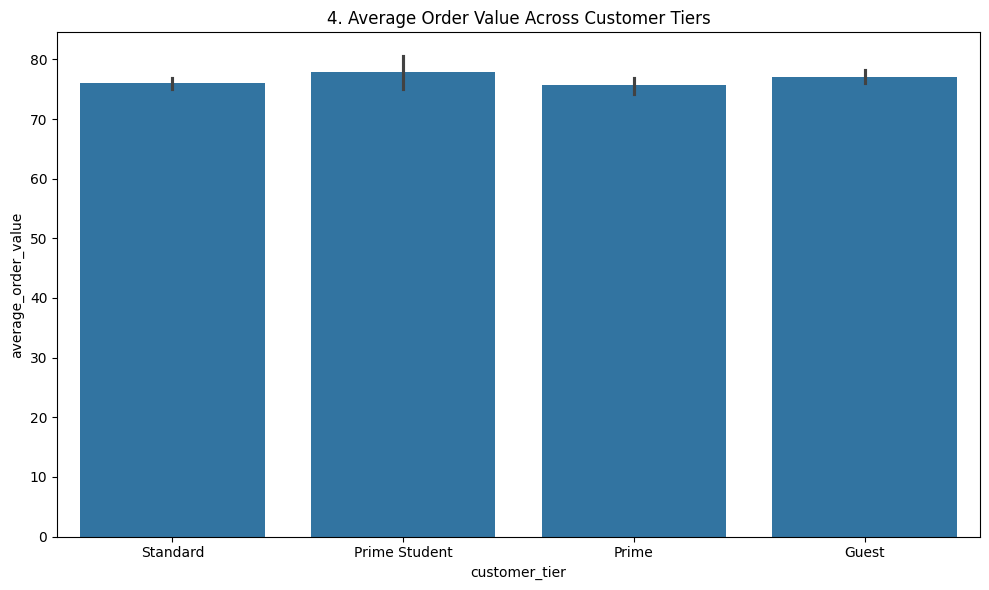

In [16]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='customer_tier', y='average_order_value', estimator='mean')
plt.title(f'{plot_no}. Average Order Value Across Customer Tiers')
show_fig()
plot_no += 1

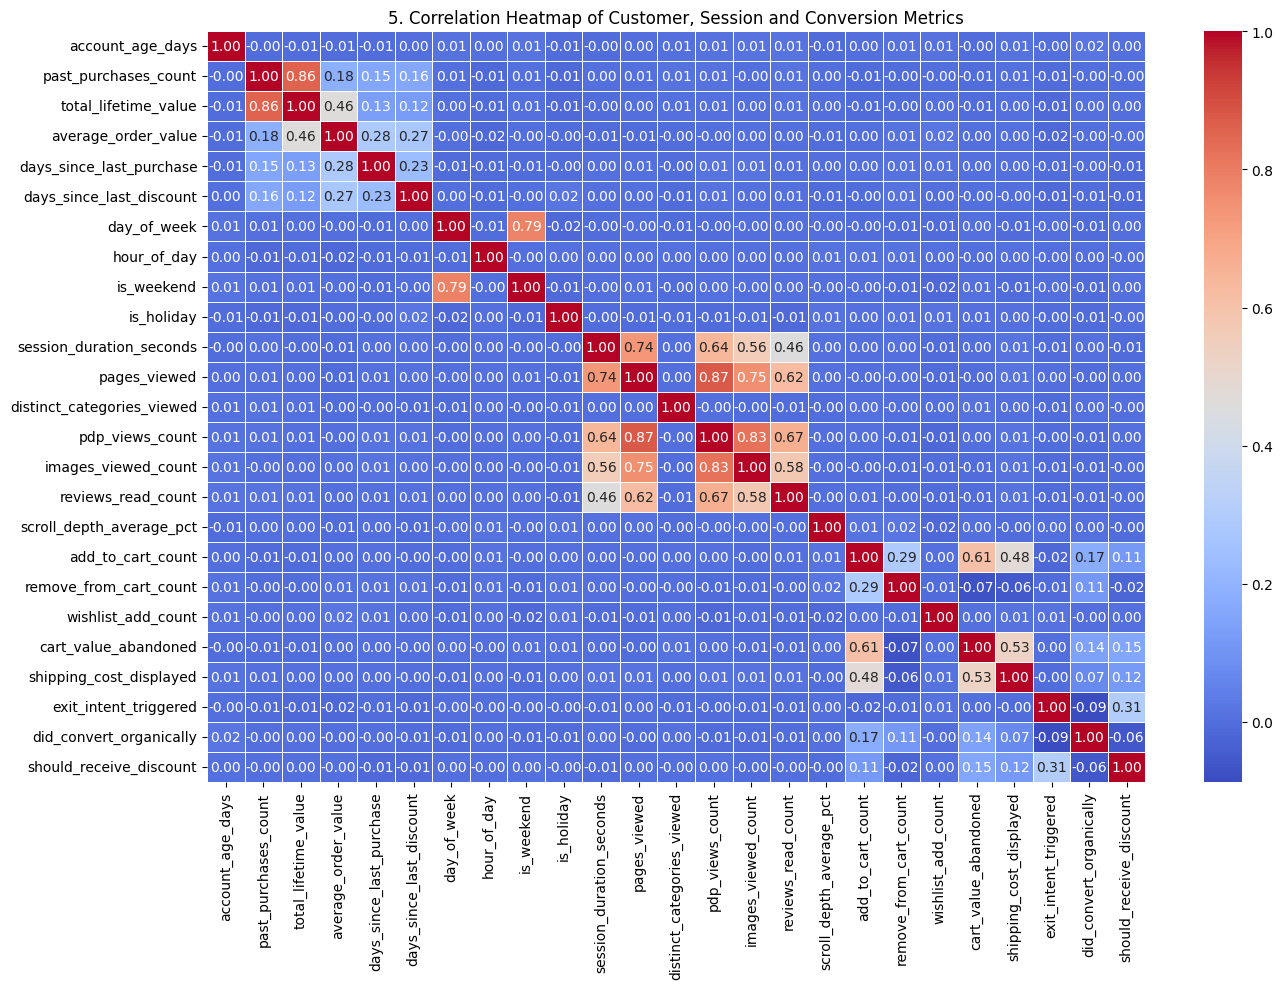

In [17]:
fig = plt.figure(figsize=(14,10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Customer, Session and Conversion Metrics')
show_fig()
plot_no += 1

# Model Training

## Select target and remove identifiers

In [18]:
X = df.drop(columns=['did_convert_organically', 'user_id', 'session_id'])
y = df['did_convert_organically']

## Remove highly redundant features

In [19]:
X = X.drop(columns=[
    'pdp_views_count',
    'images_viewed_count',
    'reviews_read_count',
    'is_weekend'
], errors='ignore')

## Identify feature types

In [20]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

## Build preprocessing pipeline

In [21]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

## Split data with stratification

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## Train strongly regularized logistic regression

In [23]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=0.03,
        penalty='l2',
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

## Train the model

In [24]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [25]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Calculate accuracy

In [26]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

## Print model performance

In [27]:
print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Testing Accuracy: {test_accuracy:.2%}")
print(f"Overfitting Gap: {(train_accuracy - test_accuracy):.2%}")

Training Accuracy: 84.59%
Testing Accuracy: 84.37%
Overfitting Gap: 0.23%


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

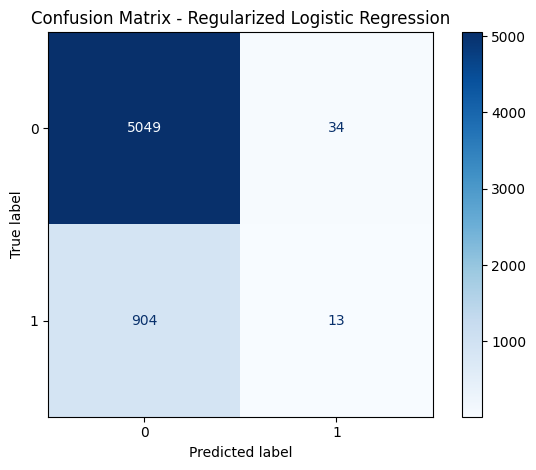

In [28]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap='Blues',
    values_format='d'
)
plt.title('Confusion Matrix - Regularized Logistic Regression')
plt.tight_layout()
plt.show()